In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test = pd.read_csv('../6.Data/Yann_Process_test.csv')

train = train.drop(columns=["account_age_days","age","num_transactions_30d","max_amount_30d_eur","secondary_email"])
test = test.drop(columns=["account_age_days","age","num_transactions_30d","max_amount_30d_eur","secondary_email"])

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [col for col in train.columns if col not in [target, id_col]]

X = train[selected_features]
y = train[target]
X_test = test[selected_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
train.head()

,customer_id,tenure_months,annual_income_eur,credit_score,avg_amount_30d_eur,days_since_last_login,support_tickets_90d,chargebacks_12m,failed_payments_6m,device_trust_z,ip_risk_z,is_vpn,num_devices_30d,partner_risk_indicator,target_is_fraud,mean_abs_internal_signal
0,CUST_6O9Q8D4I36,3.772566,0.082670,-2.140930,-0.009718,-0.610807,0.248406,-0.226198,1.155510,-0.942105,-0.355949,-0.295522,-0.651409,0.000427,0,1.021938
1,CUST_FGUGTW230C,-0.926606,-0.818677,0.558410,1.259538,-1.012352,-0.916658,-0.226198,-0.605184,-1.185147,1.702631,-0.295522,-0.651409,13.180925,0,0.737988
2,CUST_8ZI3LCBZ0W,-1.044086,-0.798750,0.847019,0.304931,-0.636995,0.248406,-0.226198,-0.605184,-0.488159,1.019438,-0.295522,-0.651409,0.000427,1,0.772720
3,CUST_5MP3AR41CJ,1.834157,0.073882,0.558410,-0.341723,1.169958,0.248406,-0.226198,1.155510,1.299504,0.684344,-0.295522,-0.651409,0.000427,0,1.128770
4,CUST_GNPL83JB0J,1.657938,-0.666900,-1.292081,0.958031,0.078803,-0.916658,4.420908,-0.605184,0.314281,-1.931394,-0.295522,-0.651409,0.000427,0,0.836278


scale_pos_weight : 10.61


Best trial: 58. Best value: 0.374461: 100%|██████████| 100/100 [24:14<00:00, 14.54s/it]



Meilleurs paramètres : {'n_estimators': 561, 'max_depth': 10, 'learning_rate': 0.026743139049937657}
Meilleur F1 CV       : 0.3745

Nombre d'arbres retenus : 45

Meilleur seuil (F1 max) : 0.616
Meilleur F1-score       : 0.3962

Confusion Matrix:
[[26317  2928]
 [ 1351  1404]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     29245
           1       0.32      0.51      0.40      2755

    accuracy                           0.87     32000
   macro avg       0.64      0.70      0.66     32000
weighted avg       0.90      0.87      0.88     32000


Average Precision Score : 0.3662
F1 final (val)          : 0.3962

Top 10 features (SHAP):


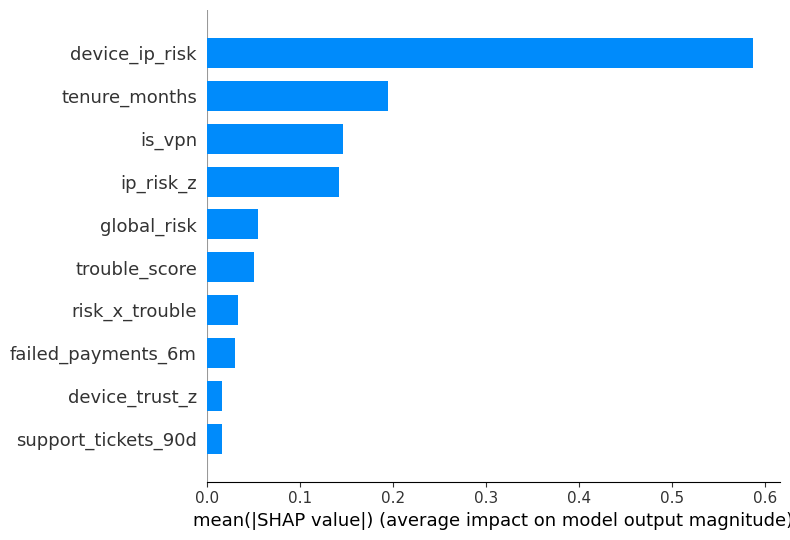


Submission sauvegardée → ../6.Data/submission.csv
target_is_fraud
0    34627
1     5373
Name: count, dtype: int64


In [19]:
import pandas as pd
import numpy as np
import optuna
import shap
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    average_precision_score,
)
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# =========================
# 1️⃣ Chargement des données
# =========================

train = pd.read_csv('../6.Data/Yann_Process_train.csv')
test  = pd.read_csv('../6.Data/Yann_Process_test.csv')

train = train.drop(columns="account_age_days")
test  = test.drop(columns="account_age_days")

target = 'target_is_fraud'
id_col = 'customer_id'

selected_features = [col for col in train.columns if col not in [target, id_col]]

# =========================
# 2️⃣ Feature Engineering
# =========================

def feature_engineering(df):
    df = df.copy()

    # Risque technique device/IP
    df['device_ip_risk']      = df['ip_risk_z'] - df['device_trust_z']

    # Historique de problèmes
    df['trouble_score']       = (df['chargebacks_12m']
                                 + df['failed_payments_6m']
                                 + df['support_tickets_90d'])


    # Score de risque global
    df['global_risk']         = (df['ip_risk_z'] + df['trouble_score']) * (1 - df['device_trust_z'])

    # Interactions
    df['risk_x_trouble']      = df['ip_risk_z'] * df['trouble_score']

    return df


train = feature_engineering(train)
test  = feature_engineering(test)

# Mise à jour des features après engineering
selected_features = [col for col in train.columns if col not in [target, id_col]]

X       = train[selected_features]
y       = train[target]
X_test  = test[selected_features]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =========================
# 3️⃣ Gestion déséquilibre
# =========================

scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale:.2f}")

# =========================
# 4️⃣ Optimisation Optuna (objectif = F1)
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'scale_pos_weight':  scale,
        'random_state':      42,
        'n_jobs':            -1,
        'eval_metric':       'aucpr',
        'use_label_encoder': False,
    }

    model = XGBClassifier(**params)

    # Scoring F1 en cross-validation (seuil 0.5 par défaut ici,
    # affiné au step 5 sur le jeu de validation)
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nMeilleurs paramètres : {study.best_params}")
print(f"Meilleur F1 CV       : {study.best_value:.4f}")

# =========================
# 5️⃣ Entraînement final + Early Stopping
# =========================

best_params = study.best_params.copy()
n_est = best_params.pop('n_estimators')

final_model = XGBClassifier(
    **best_params,
    n_estimators=1000,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr',
    early_stopping_rounds=50,   # ← déplacé ici dans le constructeur
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"\nNombre d'arbres retenus : {final_model.best_iteration}")

# =========================
# 6️⃣ Recherche du meilleur seuil (max F1 sur validation)
# =========================

y_proba = final_model.predict_proba(X_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba)

f1_scores = (2 * precisions[:-1] * recalls[:-1]
             / (precisions[:-1] + recalls[:-1] + 1e-9))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nMeilleur seuil (F1 max) : {best_threshold:.3f}")
print(f"Meilleur F1-score       : {f1_scores[best_idx]:.4f}")

# =========================
# 7️⃣ Évaluation finale
# =========================

y_pred = (y_proba >= best_threshold).astype(int)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print(f"\nAverage Precision Score : {average_precision_score(y_val, y_proba):.4f}")
print(f"F1 final (val)          : {f1_score(y_val, y_pred):.4f}")

# =========================
# 8️⃣ Analyse SHAP (top features)
# =========================

explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
print("\nTop 10 features (SHAP):")
shap.summary_plot(shap_values, X_val, max_display=10, plot_type='bar')

# =========================
# 9️⃣ Prédictions finales sur le test
# =========================

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    id_col:          test[id_col],
    'proba_fraud':   test_proba,
    target:          test_pred,
})

submission.to_csv('../6.Data/submission.csv', index=False)
print("\nSubmission sauvegardée → ../6.Data/submission.csv")
print(submission[target].value_counts())

In [21]:
import pickle

# Sauvegarde du modèle
with open("xgboost_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

print("Modèle sauvegardé avec succès.")

Modèle sauvegardé avec succès.


In [3]:
import pandas as pd 
df = pd.read_csv('../6.Data/submission.csv')
df.drop(columns="proba_fraud", inplace=True)

df.to_csv('../6.Data/submission.csv', index=False)

KeyError: "['proba_fraud'] not found in axis"